In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print("All imports OK")

All imports OK


In [3]:
# Load raw data
df = pd.read_csv('../data/smart_home.csv', low_memory=False)

# Drop the time column — it is a row counter, not a real timestamp
df = df.drop(columns=['time'])

# Rebuild a correct datetime index: 1 minute per row, starting Jan 1 2016
df.index = pd.date_range(start='2016-01-01 00:00:00', periods=len(df), freq='1min')
df.index.name = 'time'

# Fix cloudCover — contains mixed strings and numbers, force to numeric
df['cloudCover'] = pd.to_numeric(df['cloudCover'], errors='coerce')

print(f"Shape: {df.shape}")
print(f"Start: {df.index.min()}")
print(f"End: {df.index.max()}")
print(f"Total days: {(df.index.max() - df.index.min()).days}")

Shape: (503910, 31)
Start: 2016-01-01 00:00:00
End: 2016-12-15 22:29:00
Total days: 349


In [4]:
# Column types and non-null counts
print("=== COLUMN INFO ===")
print(df.info())

print("\n=== NUMERIC SUMMARY ===")
print(df.describe())

=== COLUMN INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503910 entries, 2016-01-01 00:00:00 to 2016-12-15 22:29:00
Freq: min
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   use [kW]             503910 non-null  float64
 1   gen [kW]             503910 non-null  float64
 2   House overall [kW]   503910 non-null  float64
 3   Dishwasher [kW]      503910 non-null  float64
 4   Furnace 1 [kW]       503910 non-null  float64
 5   Furnace 2 [kW]       503910 non-null  float64
 6   Home office [kW]     503910 non-null  float64
 7   Fridge [kW]          503910 non-null  float64
 8   Wine cellar [kW]     503910 non-null  float64
 9   Garage door [kW]     503910 non-null  float64
 10  Kitchen 12 [kW]      503910 non-null  float64
 11  Kitchen 14 [kW]      503910 non-null  float64
 12  Kitchen 38 [kW]      503910 non-null  float64
 13  Barn [kW]            503910 non-null  float64
 14  Well

## Data Loading & Initial Inspection

**Dataset:** Smart Home with Weather Information (2016)  
**Source:** Kaggle — taranvee  
**Resolution:** 1 minute per row  
**Coverage:** 2016-01-01 to 2016-12-15 (349 days)  

**Key findings from inspection:**
- 31 columns: 18 appliance/power readings, 11 weather features, 2 text columns
- No missing values except cloudCover (58 rows — corrupted string values, coerced to NaN)
- Kitchen 38 is a dead sensor (max 0.0002 kW) — will be dropped
- gen [kW] and Solar [kW] are identical — will keep Solar, drop gen
- icon and summary are text weather labels — no value to the model, will be dropped
- Temperature is in Fahrenheit (range -12 to 93) — US household confirmed

In [5]:
# Drop dead sensor, duplicate solar column, and text weather columns
df = df.drop(columns=[
    'Kitchen 38 [kW]',   # dead sensor, zero readings all year
    'gen [kW]',          # identical to Solar [kW]
    'icon',              # text label, no numeric value
    'summary',           # text label, no numeric value
], errors='ignore')      # safe to re-run — skips already-dropped columns

# Forward-fill the 58 cloudCover nulls
df['cloudCover'] = df['cloudCover'].ffill().bfill()

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nFinal columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col}")

Shape after cleaning: (503910, 27)
Remaining nulls: 0

Final columns (27):
  use [kW]
  House overall [kW]
  Dishwasher [kW]
  Furnace 1 [kW]
  Furnace 2 [kW]
  Home office [kW]
  Fridge [kW]
  Wine cellar [kW]
  Garage door [kW]
  Kitchen 12 [kW]
  Kitchen 14 [kW]
  Barn [kW]
  Well [kW]
  Microwave [kW]
  Living room [kW]
  Solar [kW]
  temperature
  humidity
  visibility
  apparentTemperature
  pressure
  windSpeed
  cloudCover
  windBearing
  precipIntensity
  dewPoint
  precipProbability


In [6]:
# Resample from 1-minute to hourly
# Mean is correct for power (kW) — average power over the hour
# Mean is also correct for weather — slow-changing variables

power_cols = [col for col in df.columns if '[kW]' in col]
weather_cols = ['temperature', 'humidity', 'visibility', 'apparentTemperature',
                'pressure', 'windSpeed', 'cloudCover', 'windBearing',
                'precipIntensity', 'dewPoint', 'precipProbability']

df_hourly = pd.concat([
    df[power_cols].resample('1h').mean(),
    df[weather_cols].resample('1h').mean(),
], axis=1)

print(f"Hourly shape: {df_hourly.shape}")
print(f"Expected: ~8,400 rows (349 days × 24 hours)")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")
print(f"Nulls after resampling: {df_hourly.isnull().sum().sum()}")

Hourly shape: (8399, 27)
Expected: ~8,400 rows (349 days × 24 hours)
Date range: 2016-01-01 00:00:00 to 2016-12-15 22:00:00
Nulls after resampling: 0


## Resampling

Resampled from 1-minute to 1-hour resolution using mean aggregation.
- Power columns: mean kW over each hour
- Weather columns: mean over each hour (slow-changing variables)
- Result: 8,399 hourly rows covering 349 days
- Zero nulls after resampling

In [7]:
import os

os.makedirs('../data/processed', exist_ok=True)
df_hourly.to_csv('../data/processed/hourly_data.csv')

print("Saved to data/processed/hourly_data.csv")
print(f"File size: {os.path.getsize('../data/processed/hourly_data.csv') / 1024:.1f} KB")

Saved to data/processed/hourly_data.csv
File size: 3796.7 KB


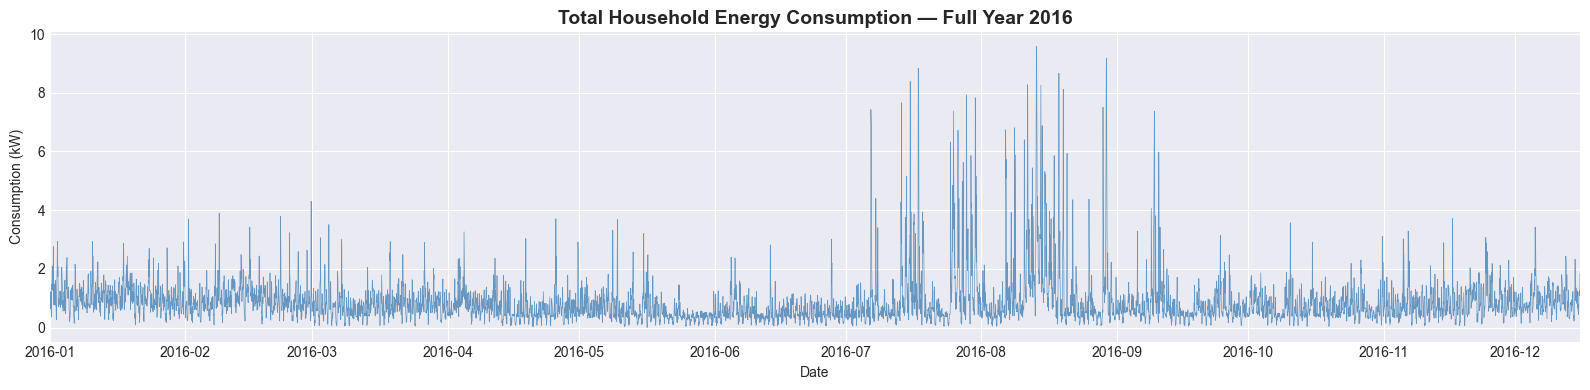

Mean consumption: 0.859 kW
Max consumption:  9.580 kW
Min consumption:  0.001 kW


In [8]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_hourly.index, df_hourly['use [kW]'], 
        color='steelblue', linewidth=0.5, alpha=0.8)

ax.set_title('Total Household Energy Consumption — Full Year 2016', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consumption (kW)')
ax.set_xlim(df_hourly.index.min(), df_hourly.index.max())

plt.tight_layout()
plt.show()

print(f"Mean consumption: {df_hourly['use [kW]'].mean():.3f} kW")
print(f"Max consumption:  {df_hourly['use [kW]'].max():.3f} kW")
print(f"Min consumption:  {df_hourly['use [kW]'].min():.3f} kW")

### Chart 1: Full Year Time Series
- Baseline consumption: 0.5–2 kW throughout the year (always-on appliances)
- July–September shows dramatically higher consumption and volatility — HVAC cooling during peak US summer
- Frequent short spikes across all months — high-draw appliances (microwave, barn, washing machine)
- No flat/dead periods — sensor was active and recording all year

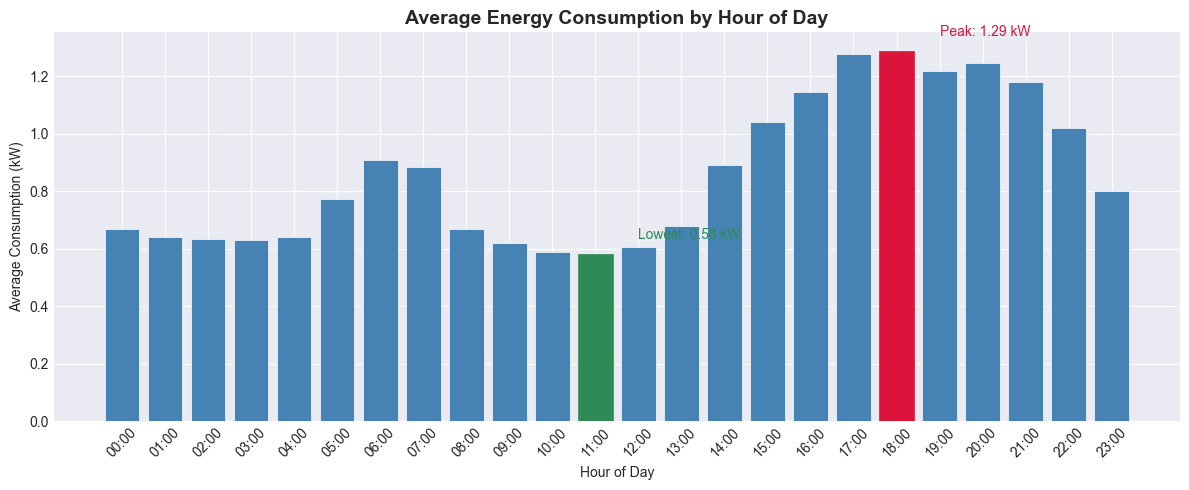

Peak hour: 18:00 — 1.288 kW
Lowest hour: 11:00 — 0.582 kW


In [9]:
hourly_avg = df_hourly.groupby(df_hourly.index.hour)['use [kW]'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(hourly_avg.index, hourly_avg.values, 
              color='steelblue', edgecolor='white', linewidth=0.5)

# Highlight peak and trough
peak_hour = hourly_avg.idxmax()
trough_hour = hourly_avg.idxmin()
bars[peak_hour].set_color('crimson')
bars[trough_hour].set_color('seagreen')

ax.set_title('Average Energy Consumption by Hour of Day', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Consumption (kW)')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)

ax.annotate(f'Peak: {hourly_avg[peak_hour]:.2f} kW', 
            xy=(peak_hour, hourly_avg[peak_hour]),
            xytext=(peak_hour + 1, hourly_avg[peak_hour] + 0.05),
            fontsize=10, color='crimson')

ax.annotate(f'Lowest: {hourly_avg[trough_hour]:.2f} kW', 
            xy=(trough_hour, hourly_avg[trough_hour]),
            xytext=(trough_hour + 1, hourly_avg[trough_hour] + 0.05),
            fontsize=10, color='seagreen')

plt.tight_layout()
plt.show()

print(f"Peak hour: {peak_hour}:00 — {hourly_avg[peak_hour]:.3f} kW")
print(f"Lowest hour: {trough_hour}:00 — {hourly_avg[trough_hour]:.3f} kW")

### Chart 2: Average Consumption by Hour of Day
- Clear bimodal pattern: morning rise (6am), midday trough (11am), evening peak (6pm)
- 11am is the optimal window for flexible appliance scheduling — lowest average demand
- 6pm is the worst time to run high-draw appliances — peak household activity
- This daily rhythm is the primary pattern the XGBoost model will learn from

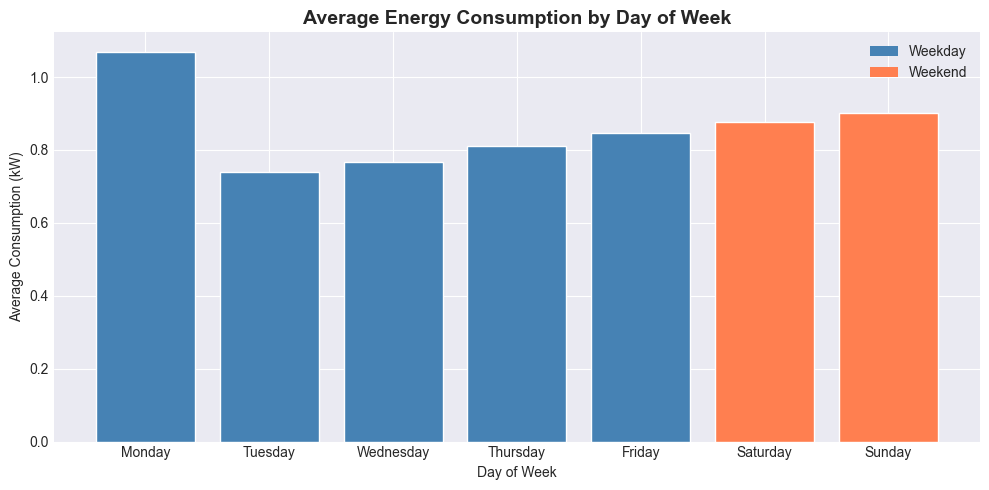

Monday: 1.069 kW
Tuesday: 0.740 kW
Wednesday: 0.767 kW
Thursday: 0.811 kW
Friday: 0.846 kW
Saturday: 0.877 kW
Sunday: 0.903 kW


In [10]:
day_avg = df_hourly.groupby(df_hourly.index.dayofweek)['use [kW]'].mean()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue' if i < 5 else 'coral' for i in range(7)]
bars = ax.bar(day_names, day_avg.values, color=colors, edgecolor='white')

ax.set_title('Average Energy Consumption by Day of Week', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Consumption (kW)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='coral', label='Weekend')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

for day, val in zip(day_names, day_avg.values):
    print(f"{day}: {val:.3f} kW")

### Chart 3: Average Consumption by Day of Week
- Monday is highest — likely HVAC recovery and weekly routine startup
- Tuesday is the most efficient day — mid-week routine, house empty during work hours
- Weekend consumption is higher than mid-week but lower than Monday
- Sunday is the highest weekend day — home day, cooking, laundry
- Day of week is a meaningful predictor — will be included as a model feature

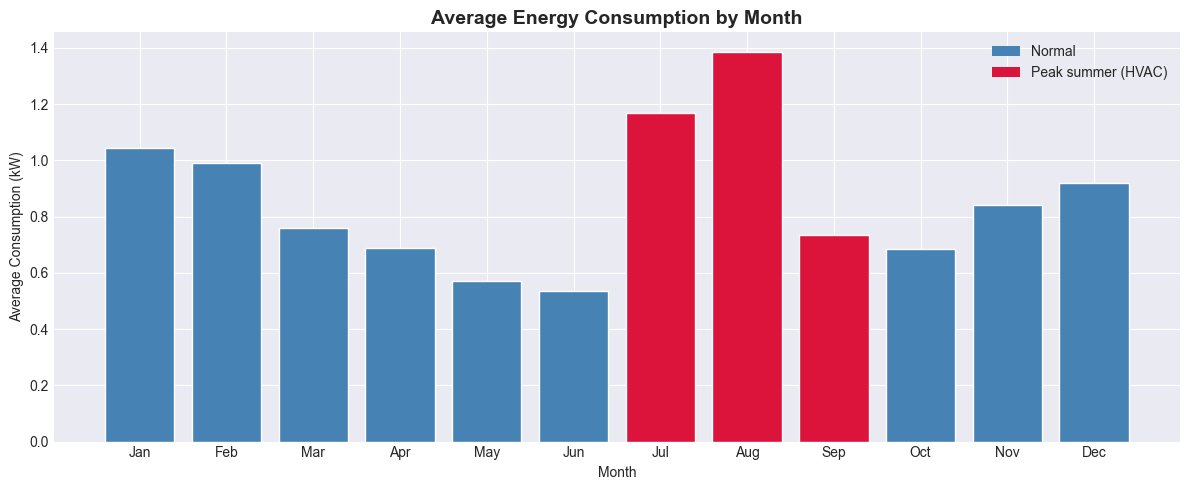

Jan: 1.046 kW
Feb: 0.992 kW
Mar: 0.761 kW
Apr: 0.689 kW
May: 0.571 kW
Jun: 0.536 kW
Jul: 1.169 kW
Aug: 1.386 kW
Sep: 0.735 kW
Oct: 0.683 kW
Nov: 0.840 kW
Dec: 0.921 kW


In [11]:
monthly_avg = df_hourly.groupby(df_hourly.index.month)['use [kW]'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue'] * 12
for i in [6, 7, 8]:
    colors[i] = 'crimson'

bars = ax.bar(month_names[:len(monthly_avg)], 
              monthly_avg.values,
              color=colors[:len(monthly_avg)],
              edgecolor='white')

ax.set_title('Average Energy Consumption by Month', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Consumption (kW)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Normal'),
                   Patch(facecolor='crimson', label='Peak summer (HVAC)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

for month, val in zip(month_names[:len(monthly_avg)], monthly_avg.values):
    print(f"{month}: {val:.3f} kW")

### Chart 4: Average Consumption by Month
- Clear U-shaped seasonal pattern: high winter, low spring, high summer, declining autumn
- July and August peak due to HVAC air conditioning (temperatures reaching 93F)
- January elevated due to winter heating (temperatures dropping to -12F)
- June is the most efficient month — mild weather, minimal HVAC load
- Month is a critical model feature — captures seasonal HVAC behaviour

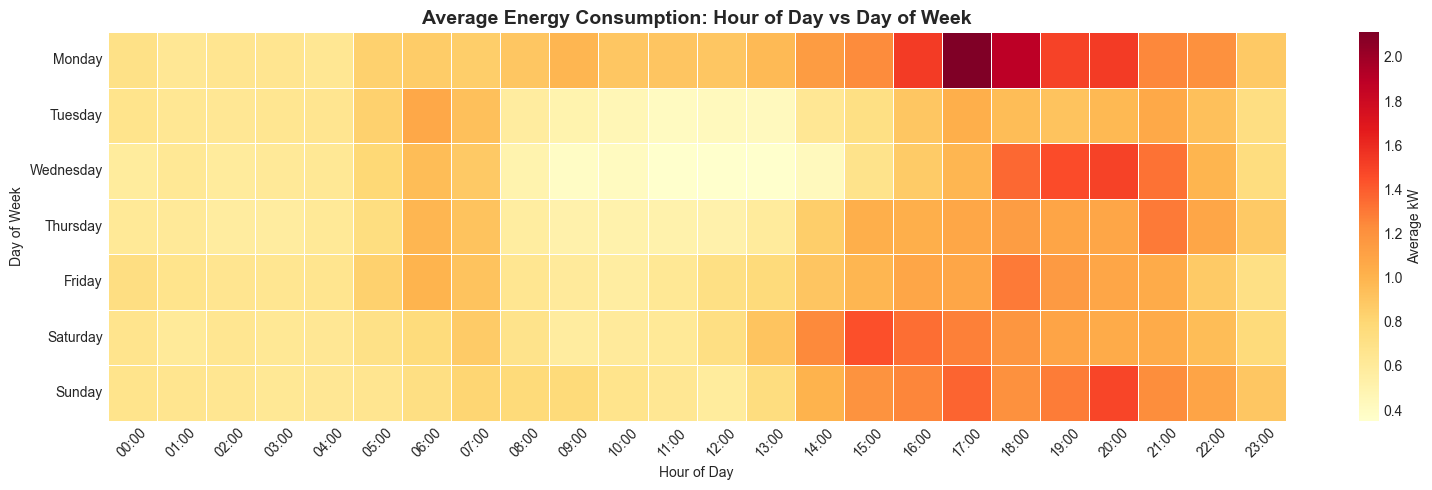

In [12]:
# Pivot table: rows = day of week, columns = hour of day
heatmap_data = df_hourly.copy()
heatmap_data['hour'] = heatmap_data.index.hour
heatmap_data['day_of_week'] = heatmap_data.index.dayofweek

pivot = heatmap_data.pivot_table(
    values='use [kW]',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

pivot.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(pivot, 
            ax=ax,
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            annot=False,
            fmt='.2f',
            cbar_kws={'label': 'Average kW'})

ax.set_title('Average Energy Consumption: Hour of Day vs Day of Week', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)

plt.tight_layout()
plt.show()

### Chart 5: Heatmap — Hour of Day vs Day of Week
- Monday 5pm is the single highest consumption cell in the entire dataset
- Consistent low-consumption window: 8am-3pm across all weekdays (house empty)
- Saturday peaks at 3pm — home all day, afternoon activity pattern
- Tuesday is the most uniformly low-consumption day
- Hour x day combinations matter more than either dimension alone
- XGBoost will learn these interactions automatically through feature splits

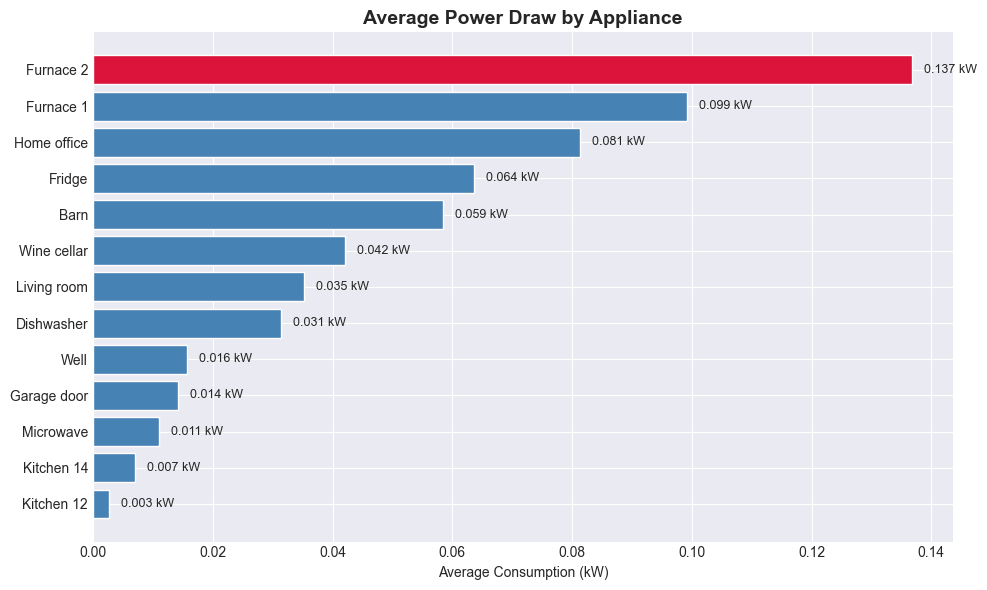

Average power draw per appliance:
  Furnace 2            0.1368 kW
  Furnace 1            0.0992 kW
  Home office          0.0813 kW
  Fridge               0.0636 kW
  Barn                 0.0585 kW
  Wine cellar          0.0421 kW
  Living room          0.0353 kW
  Dishwasher           0.0314 kW
  Well                 0.0156 kW
  Garage door          0.0141 kW
  Microwave            0.0110 kW
  Kitchen 14           0.0070 kW
  Kitchen 12           0.0028 kW


In [13]:
appliance_cols = [
    'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]',
    'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]',
    'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]',
    'Barn [kW]', 'Well [kW]', 'Microwave [kW]', 'Living room [kW]'
]

# Total consumption per appliance across the year (kW mean * 8399 hours)
appliance_totals = df_hourly[appliance_cols].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['crimson' if v == appliance_totals.max() else 'steelblue' 
          for v in appliance_totals.values]

bars = ax.barh(
    [col.replace(' [kW]', '') for col in appliance_totals.index],
    appliance_totals.values,
    color=colors,
    edgecolor='white'
)

ax.set_title('Average Power Draw by Appliance', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Consumption (kW)')

for bar, val in zip(bars, appliance_totals.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f} kW', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Average power draw per appliance:")
for col, val in appliance_totals.sort_values(ascending=False).items():
    print(f"  {col.replace(' [kW]', ''):<20} {val:.4f} kW")

### Chart 6: Average Power Draw by Appliance
- Furnace 1 and 2 (HVAC) dominate consumption but are not schedulable
- Flexible appliances suitable for optimizer recommendations: Dishwasher, Microwave
- Always-on loads (Fridge, Home office, Wine cellar): cannot be scheduled
- Optimizer will focus recommendations on genuinely flexible, schedulable appliances

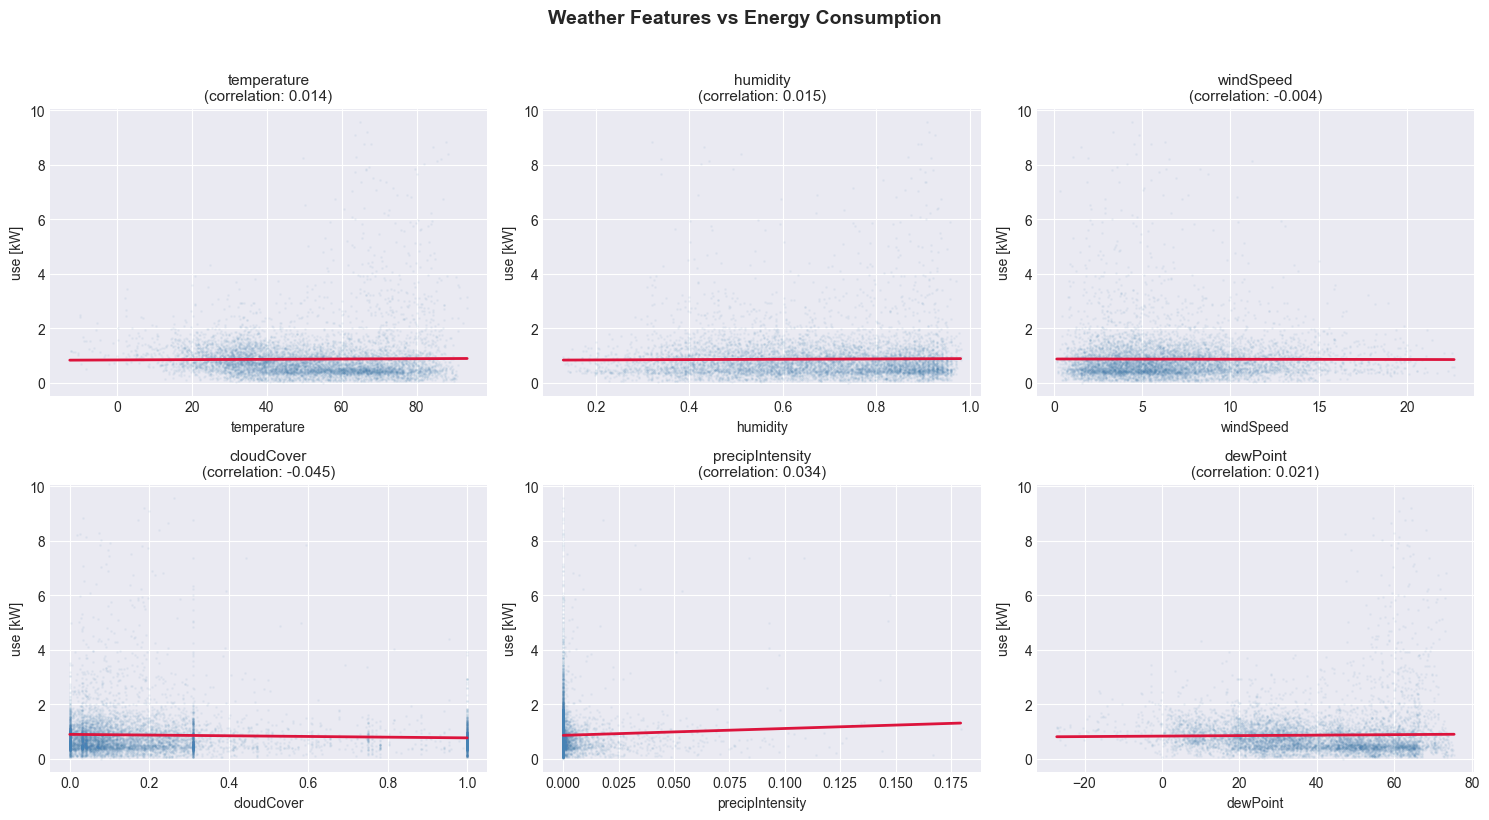

Correlations with use [kW]:
  temperature          +0.0137
  humidity             +0.0149
  windSpeed            -0.0045
  cloudCover           -0.0449
  precipIntensity      +0.0337
  dewPoint             +0.0210


In [14]:
weather_features = ['temperature', 'humidity', 'windSpeed', 
                    'cloudCover', 'precipIntensity', 'dewPoint']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(weather_features):
    axes[i].scatter(df_hourly[feature], df_hourly['use [kW]'],
                   alpha=0.05, color='steelblue', s=1)
    
    # Add trend line
    z = np.polyfit(df_hourly[feature].dropna(), 
                   df_hourly.loc[df_hourly[feature].notna(), 'use [kW]'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df_hourly[feature].dropna())
    axes[i].plot(x_sorted, p(x_sorted), color='crimson', linewidth=2)
    
    corr = df_hourly['use [kW]'].corr(df_hourly[feature])
    axes[i].set_title(f'{feature}\n(correlation: {corr:.3f})', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('use [kW]')

plt.suptitle('Weather Features vs Energy Consumption', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Correlations with use [kW]:")
for feature in weather_features:
    corr = df_hourly['use [kW]'].corr(df_hourly[feature])
    print(f"  {feature:<20} {corr:+.4f}")

### Chart 7: Weather Correlations with Consumption
- All weather features show near-zero linear correlation with hourly consumption
- Strongest: cloudCover (-0.045), still essentially negligible
- Weather affects consumption seasonally (monthly aggregates) not hourly
- The dominant hourly drivers are behavioural: time of day, day of week, recent habits
- Weather features will still be included in the model for non-linear interactions
- XGBoost will capture weather effects through tree splits, not linear correlation